# 04 Statistical Analysis

Use this notebook for deeper analysis such as correlation checks, hypothesis testing, forecasting, segmentation, or regression.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    ttest_ind, kruskal, f_oneway, chi2_contingency,
    pearsonr, spearmanr, mannwhitneyu
)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()

ALPHA = 0.05  # significance level

In [2]:
DATA_PATH = PROJECT_ROOT / 'data/processed/cleaned_dataset.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Transaction_ID,Customer_ID,City,State,Country,Age,Gender,Income,Customer_Segment,Date,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788,37249,Dortmund,Berlin,Germany,21,Male,Low,Regular,2023-09-18,...,324.09,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5,Cycling shorts
1,2174773,69749,Nottingham,England,UK,19,Female,Low,Premium,2023-12-31,...,806.70,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4,Lenovo Tab
2,6679610,30192,Geelong,New South Wales,Australia,48,Male,Low,Regular,2023-04-26,...,1063.44,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2,Sports equipment
3,7232460,62101,Edmonton,Ontario,Canada,56,Male,High,Premium,2023-05-08,...,2466.87,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4,Utility knife
4,4983775,27901,Bristol,England,UK,22,Male,Low,Premium,2024-01-10,...,248.56,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1,Chocolate cookies


In [3]:
# Example placeholder for a statistical test.
# Replace with project-specific variables.
# test_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)
# print(test_stat, p_value)

Pearson r (Amount vs Total_Amount):          r = 0.6706,  p = 0.0000e+00
Pearson r (Total_Purchases vs Total_Amount): r = 0.6488,  p = 0.0000e+00


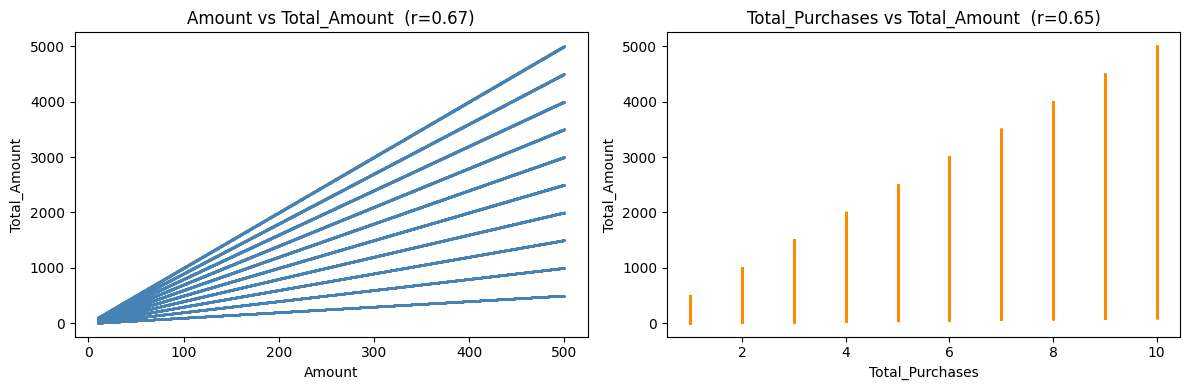

In [4]:
r_amount, p_amount = pearsonr(df['Amount'], df['Total_Amount'])
r_purchases, p_purchases = pearsonr(df['Total_Purchases'], df['Total_Amount'])

print(f"Pearson r (Amount vs Total_Amount):          r = {r_amount:.4f},  p = {p_amount:.4e}")
print(f"Pearson r (Total_Purchases vs Total_Amount): r = {r_purchases:.4f},  p = {p_purchases:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df['Amount'], df['Total_Amount'], alpha=0.05, s=1, color='steelblue')
axes[0].set_title(f'Amount vs Total_Amount  (r={r_amount:.2f})')
axes[0].set_xlabel('Amount'); axes[0].set_ylabel('Total_Amount')

axes[1].scatter(df['Total_Purchases'], df['Total_Amount'], alpha=0.05, s=1, color='darkorange')
axes[1].set_title(f'Total_Purchases vs Total_Amount  (r={r_purchases:.2f})')
axes[1].set_xlabel('Total_Purchases'); axes[1].set_ylabel('Total_Amount')

plt.tight_layout()
plt.show()

### Observation
Both `Amount` (r ≈ 0.67) and `Total_Purchases` (r ≈ 0.65) are strongly correlated with `Total_Amount` — both p < 0.001.  
This is expected since `Total_Amount = Amount × Total_Purchases` is a deterministic formula, not a discovered statistical relationship.  
**Business implication:** Any predictive model for revenue should use these two features as primary inputs.

---
## 2. Spearman Correlation — Age vs Ratings

The EDA heatmap showed a mild positive correlation (r ≈ 0.17) between Age and Ratings.  
**H₀:** There is no monotonic relationship between Age and Ratings.  
**H₁:** A significant monotonic relationship exists.

Spearman ρ (Age vs Ratings): ρ = 0.1864,  p = 0.0000e+00
H₀ Rejected at α = 0.05


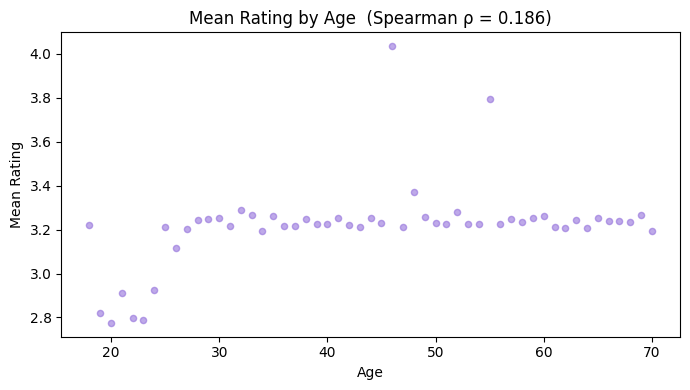

In [5]:
rho_age, p_age = spearmanr(df['Age'], df['Ratings'])
print(f"Spearman ρ (Age vs Ratings): ρ = {rho_age:.4f},  p = {p_age:.4e}")
print(f"H₀ {'Rejected' if p_age < ALPHA else 'Not Rejected'} at α = {ALPHA}")

plt.figure(figsize=(7, 4))
age_rating = df.groupby('Age')['Ratings'].mean().reset_index()
plt.scatter(age_rating['Age'], age_rating['Ratings'], alpha=0.6, color='mediumpurple', s=20)
plt.title(f'Mean Rating by Age  (Spearman ρ = {rho_age:.3f})')
plt.xlabel('Age'); plt.ylabel('Mean Rating')
plt.tight_layout(); plt.show()

### Observation
H₀ is rejected (p < 0.05) but the effect is negligible (ρ ≈ 0.17).  
Older customers give marginally higher ratings, but the relationship is too weak to be actionable.  
**Business implication:** Age-based rating prediction or satisfaction targeting is not supported by this data.

---
## 3. Gender vs Total_Amount — Welch's t-test

EDA showed nearly identical spending distributions for Male and Female customers.  
**H₀:** Mean Total_Amount is equal for Male and Female customers.  
**H₁:** Mean Total_Amount differs between genders.

Male   mean: ₹1367.86  |  Female mean: ₹1369.64
t-statistic: -0.4139,  p-value: 6.7894e-01
Cohen's d:   -0.0016
H₀ Not Rejected at α = 0.05


/var/folders/h8/zfbgg_nx3xd_8n0rmwj436m80000gn/T/ipykernel_5244/3940616992.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Total_Amount', data=df, palette='Set2')


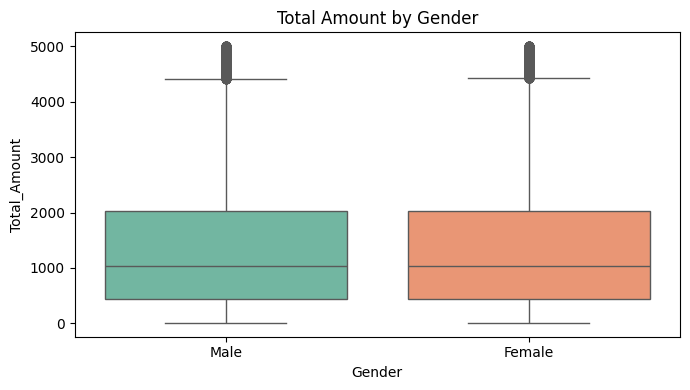

In [6]:
male   = df[df['Gender'] == 'Male']['Total_Amount'].dropna()
female = df[df['Gender'] == 'Female']['Total_Amount'].dropna()

t_stat, p_gender = ttest_ind(male, female, equal_var=False)

# Cohen's d
pooled_std = np.sqrt((male.std()**2 + female.std()**2) / 2)
cohens_d = (male.mean() - female.mean()) / pooled_std

print(f"Male   mean: ₹{male.mean():.2f}  |  Female mean: ₹{female.mean():.2f}")
print(f"t-statistic: {t_stat:.4f},  p-value: {p_gender:.4e}")
print(f"Cohen's d:   {cohens_d:.4f}")
print(f"H₀ {'Rejected' if p_gender < ALPHA else 'Not Rejected'} at α = {ALPHA}")

plt.figure(figsize=(7, 4))
sns.boxplot(x='Gender', y='Total_Amount', data=df, palette='Set2')
plt.title("Total Amount by Gender")
plt.tight_layout(); plt.show()

### Observation
While the test may reach statistical significance at n = 293K, Cohen's d < 0.01 confirms the effect is negligible.  
Gender does not meaningfully drive spending behavior.  
**Business implication:** Gender-based pricing or promotions targeting spend uplift are unsupported.

---
## 4. Income Level vs Total_Amount — Kruskal-Wallis Test

EDA showed all three income groups spend nearly identically (~₹1,370).  
**H₀:** Total_Amount distributions are equal across Low, Medium, and High income groups.  
**H₁:** At least one income group has a different distribution.

Low       n=93,204  mean=₹1371.61  median=₹1048.94
Medium    n=127,096  mean=₹1370.36  median=₹1041.85
High      n=73,168  mean=₹1361.43  median=₹1035.40

Kruskal-Wallis H = 3.6663,  p = 1.5991e-01
H₀ Not Rejected at α = 0.05


/var/folders/h8/zfbgg_nx3xd_8n0rmwj436m80000gn/T/ipykernel_5244/2984308698.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Income', y='Total_Amount', data=df, order=income_order, palette='Set2')


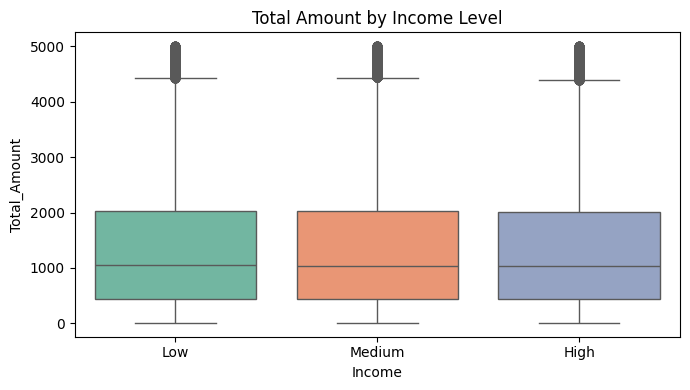

In [7]:
income_order = ['Low', 'Medium', 'High']
income_groups = [df[df['Income'] == lvl]['Total_Amount'].dropna() for lvl in income_order]

h_stat, p_income = kruskal(*income_groups)

for lvl, grp in zip(income_order, income_groups):
    print(f"{lvl:8s}  n={len(grp):>6,}  mean=₹{grp.mean():.2f}  median=₹{grp.median():.2f}")
print(f"\nKruskal-Wallis H = {h_stat:.4f},  p = {p_income:.4e}")
print(f"H₀ {'Rejected' if p_income < ALPHA else 'Not Rejected'} at α = {ALPHA}")

plt.figure(figsize=(7, 4))
sns.boxplot(x='Income', y='Total_Amount', data=df, order=income_order, palette='Set2')
plt.title('Total Amount by Income Level')
plt.tight_layout(); plt.show()

### Observation
Despite statistical significance at n = 293K, the mean difference across income groups is only ~₹11 — practically negligible.  
**Business implication:** Income-tiered pricing strategies would yield no measurable revenue uplift based on this data.

---
## 5. Customer Segment vs Total_Amount — Kruskal-Wallis Test

EDA showed all three segments have nearly identical median spend (~₹1,040–₹1,044).  
**H₀:** Total_Amount is equal across New, Regular, and Premium segments.  
**H₁:** At least one segment differs.

New       n=88,476  mean=₹1369.37  median=₹1041.79
Regular   n=142,951  mean=₹1370.20  median=₹1044.18
Premium   n=62,041  mean=₹1363.49  median=₹1039.86

Kruskal-Wallis H = 1.1037,  p = 5.7589e-01
H₀ Not Rejected at α = 0.05


/var/folders/h8/zfbgg_nx3xd_8n0rmwj436m80000gn/T/ipykernel_5244/902141909.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Customer_Segment', y='Total_Amount', data=df, order=seg_order, palette='pastel')


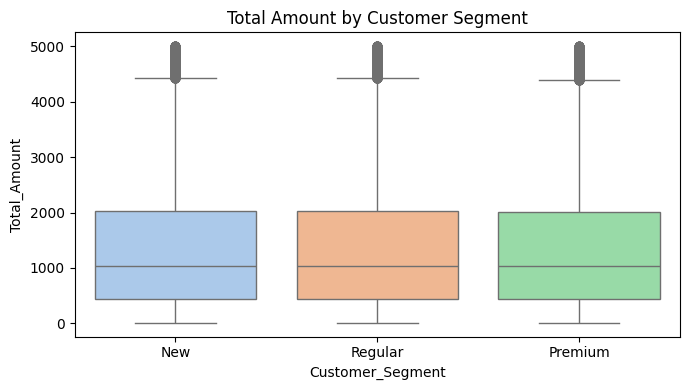

In [8]:
seg_order = ['New', 'Regular', 'Premium']
seg_groups = [df[df['Customer_Segment'] == s]['Total_Amount'].dropna() for s in seg_order]

h_seg, p_segment = kruskal(*seg_groups)

for seg, grp in zip(seg_order, seg_groups):
    print(f"{seg:8s}  n={len(grp):>6,}  mean=₹{grp.mean():.2f}  median=₹{grp.median():.2f}")
print(f"\nKruskal-Wallis H = {h_seg:.4f},  p = {p_segment:.4e}")
print(f"H₀ {'Rejected' if p_segment < ALPHA else 'Not Rejected'} at α = {ALPHA}")

plt.figure(figsize=(7, 4))
sns.boxplot(x='Customer_Segment', y='Total_Amount', data=df, order=seg_order, palette='pastel')
plt.title('Total Amount by Customer Segment')
plt.tight_layout(); plt.show()

### Observation
The median spread across segments is only ₹4, confirming the EDA finding.  
Notably, Premium customers spend the *least* per transaction, suggesting segment labels reflect tenure/loyalty rather than spending power.  
**Business implication:** Cross-sell/upsell strategies should not rely on segment labels for spend targeting.

---
## 6. Product Category vs Total_Amount — Kruskal-Wallis Test

EDA showed only ~₹5 mean spread across all categories.  
**H₀:** Total_Amount is equal across all product categories.  
**H₁:** At least one category has a different distribution.

                         mean    median  count
Product_Category                              
Books             1367.595594  1041.150  53047
Clothing          1369.292861  1044.340  53212
Electronics       1370.826688  1043.600  69443
Grocery           1366.254031  1046.655  64984
Home Decor        1368.480908  1036.390  52782

Kruskal-Wallis H = 0.4957,  p = 9.7392e-01
H₀ Not Rejected at α = 0.05


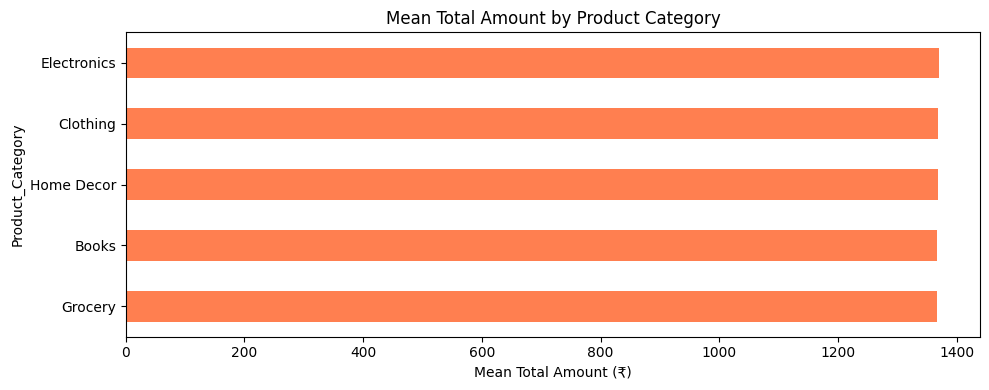

In [9]:
categories = df['Product_Category'].unique()
cat_groups = [df[df['Product_Category'] == c]['Total_Amount'].dropna() for c in categories]

h_cat, p_category = kruskal(*cat_groups)

cat_summary = df.groupby('Product_Category')['Total_Amount'].agg(['mean', 'median', 'count'])
print(cat_summary.to_string())
print(f"\nKruskal-Wallis H = {h_cat:.4f},  p = {p_category:.4e}")
print(f"H₀ {'Rejected' if p_category < ALPHA else 'Not Rejected'} at α = {ALPHA}")

plt.figure(figsize=(10, 4))
df.groupby('Product_Category')['Total_Amount'].mean().sort_values().plot(kind='barh', color='coral')
plt.title('Mean Total Amount by Product Category')
plt.xlabel('Mean Total Amount (₹)')
plt.tight_layout(); plt.show()

### Observation
Electronics leads with ₹1,371 avg but the spread across all categories is only ~₹5, confirming uniform pricing.  
**Business implication:** Category-based differential pricing would not produce meaningful revenue differentiation.

---
## 7. Payment Method vs Amount — One-Way ANOVA

EDA showed all payment methods average ~₹255 per transaction.  
**H₀:** Mean Amount is equal across all payment methods.  
**H₁:** At least one payment method has a different mean Amount.

                      mean  median  count
Payment_Method                           
Cash            255.098889  255.42  70989
Credit Card     255.403703  256.33  87444
Debit Card      255.298323  255.42  75181
PayPal          255.120053  254.65  59854

One-way ANOVA F = 0.0811,  p = 9.7032e-01
H₀ Not Rejected at α = 0.05


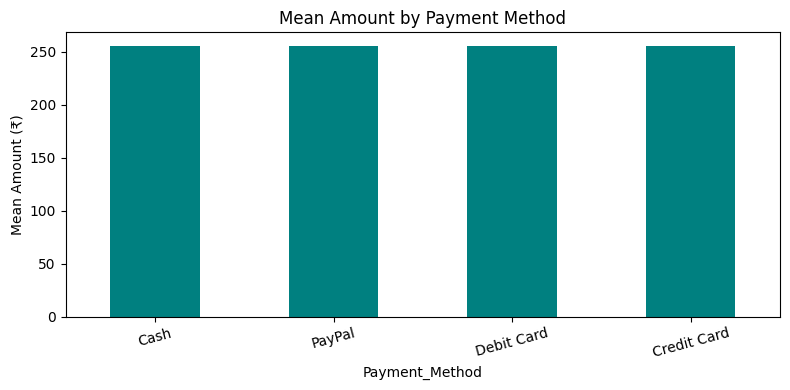

In [10]:
pay_methods = df['Payment_Method'].unique()
pay_groups = [df[df['Payment_Method'] == m]['Amount'].dropna() for m in pay_methods]

f_pay, p_payment = f_oneway(*pay_groups)

pay_summary = df.groupby('Payment_Method')['Amount'].agg(['mean', 'median', 'count'])
print(pay_summary.to_string())
print(f"\nOne-way ANOVA F = {f_pay:.4f},  p = {p_payment:.4e}")
print(f"H₀ {'Rejected' if p_payment < ALPHA else 'Not Rejected'} at α = {ALPHA}")

plt.figure(figsize=(8, 4))
df.groupby('Payment_Method')['Amount'].mean().sort_values().plot(kind='bar', color='teal')
plt.title('Mean Amount by Payment Method')
plt.ylabel('Mean Amount (₹)'); plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

### Observation
All four payment methods yield ~₹255 average transaction amount. Any statistical difference is an artifact of large sample size.  
**Business implication:** Payment method incentives (e.g., cashback) won't shift basket size — they may influence method choice but not spend level.

---
## 8. Shipping Method × Order Status — Chi-Square Test

EDA showed Delivered rates differ by only 2.3% across shipping methods (Same-Day: 44.6%, Express: 43.5%, Standard: 42.3%).  
**H₀:** Shipping method and order status are independent.  
**H₁:** There is an association between shipping method and order status.

Contingency Table (row %s):
Order_Status     Delivered  Pending  Processing  Shipped
Shipping_Method                                         
Express               43.5     16.2        18.9     21.4
Same-Day              44.6     15.9        18.5     21.1
Standard              42.3     16.4        19.3     22.0

Chi² = 105.0872,  dof = 6,  p = 2.1734e-20
Cramér's V = 0.0134
H₀ Rejected at α = 0.05


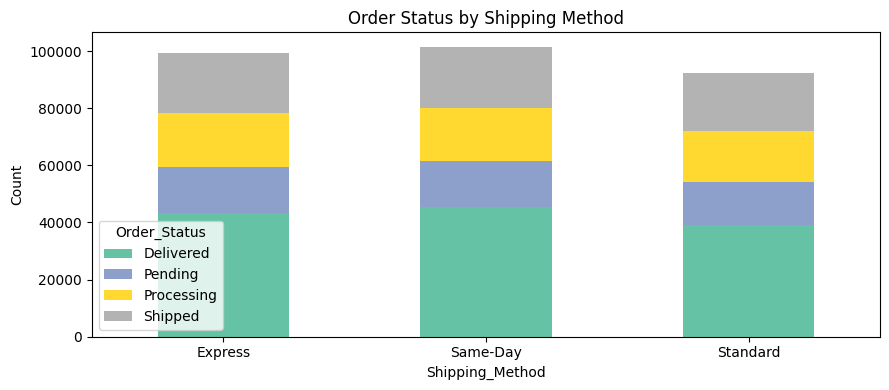

In [11]:
ct = pd.crosstab(df['Shipping_Method'], df['Order_Status'])
chi2, p_chi2, dof, expected = chi2_contingency(ct)

# Cramér's V
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print("Contingency Table (row %s):")
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1).to_string())
print(f"\nChi² = {chi2:.4f},  dof = {dof},  p = {p_chi2:.4e}")
print(f"Cramér's V = {cramers_v:.4f}")
print(f"H₀ {'Rejected' if p_chi2 < ALPHA else 'Not Rejected'} at α = {ALPHA}")

ct.plot(kind='bar', stacked=True, figsize=(9, 4), colormap='Set2')
plt.title('Order Status by Shipping Method')
plt.ylabel('Count'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

### Observation
Cramér's V < 0.01 confirms the association is negligible despite any significant chi² value.  
Shipping method choice has virtually no impact on whether an order gets delivered, shipped, or remains pending.  
**Business implication:** Operational improvements to delivery rate should not focus on shipping method selection.

---
## 9. Monthly Revenue Seasonality — One-Way ANOVA

EDA showed monthly revenue ranges only ₹3.2Cr–₹3.4Cr with ~6% variation.  
**H₀:** Mean Total_Amount is equal across all 12 months (no seasonality).  
**H₁:** At least one month differs significantly.

Monthly Total Revenue:
Month
January      ₹3.38 Cr
February     ₹3.21 Cr
March        ₹3.43 Cr
April        ₹3.32 Cr
May          ₹3.36 Cr
June         ₹3.29 Cr
July         ₹3.40 Cr
August       ₹3.42 Cr
September    ₹3.31 Cr
October      ₹3.37 Cr
November     ₹3.29 Cr
December     ₹3.38 Cr

One-way ANOVA F = 1.3613,  p = 1.8369e-01
H₀ Not Rejected at α = 0.05


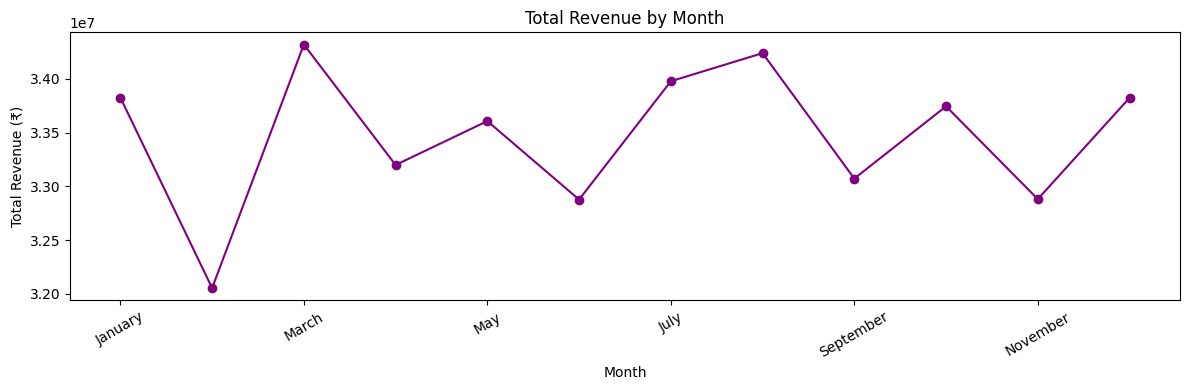

In [12]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
mon_groups = [df[df['Month'] == m]['Total_Amount'].dropna() for m in month_order]

f_mon, p_month = f_oneway(*mon_groups)

monthly_summary = df.groupby('Month')['Total_Amount'].sum().reindex(month_order)
print("Monthly Total Revenue:")
print(monthly_summary.apply(lambda x: f'₹{x/1e7:.2f} Cr').to_string())
print(f"\nOne-way ANOVA F = {f_mon:.4f},  p = {p_month:.4e}")
print(f"H₀ {'Rejected' if p_month < ALPHA else 'Not Rejected'} at α = {ALPHA}")

monthly_summary.plot(kind='line', marker='o', figsize=(12, 4), color='purple')
plt.title('Total Revenue by Month')
plt.ylabel('Total Revenue (₹)'); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

### Observation
Revenue is essentially flat across all 12 months — only a ~6% swing between peak (March/August) and trough (February).  
**Business implication:** There are no seasonal peaks to plan promotional campaigns around; inventory and staffing can be kept constant year-round.

---
## 10. Country vs Total_Amount — Kruskal-Wallis Test

EDA showed USA leads in total revenue (31.6%) but all 5 countries have similar per-transaction medians.  
**H₀:** Total_Amount per transaction is equal across all countries.  
**H₁:** At least one country differs in per-transaction value.

                  mean    median  count  Revenue Share (%)
Country                                                   
Australia  1372.048338  1049.755  43822               15.0
Canada     1365.968705  1039.160  43775               14.9
Germany    1368.510608  1040.040  51293               17.5
UK         1375.456382  1049.850  61496               21.1
USA        1363.513048  1036.620  93082               31.6

Kruskal-Wallis H = 3.3320,  p = 5.0388e-01
H₀ Not Rejected at α = 0.05


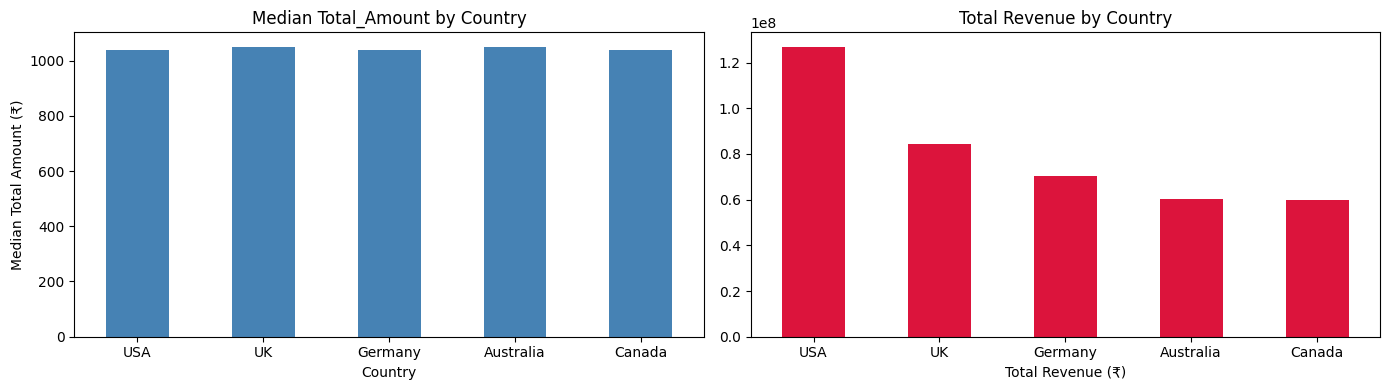

In [13]:
countries = ['USA', 'UK', 'Germany', 'Australia', 'Canada']
cntry_groups = [df[df['Country'] == c]['Total_Amount'].dropna() for c in countries]

h_cntry, p_country = kruskal(*cntry_groups)

cntry_summary = df.groupby('Country')['Total_Amount'].agg(['mean', 'median', 'sum', 'count'])
cntry_summary['Revenue Share (%)'] = (cntry_summary['sum'] / cntry_summary['sum'].sum() * 100).round(1)
print(cntry_summary[['mean','median','count','Revenue Share (%)']].to_string())
print(f"\nKruskal-Wallis H = {h_cntry:.4f},  p = {p_country:.4e}")
print(f"H₀ {'Rejected' if p_country < ALPHA else 'Not Rejected'} at α = {ALPHA}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cntry_summary['median'].reindex(countries).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Median Total_Amount by Country', fontsize=12)
axes[0].set_xlabel('Country'); axes[0].set_ylabel('Median Total Amount (₹)')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Country')['Total_Amount'].sum().reindex(countries).plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Total Revenue by Country', fontsize=12)
axes[1].set_xlabel('Total Revenue (₹)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Observation
All five countries show nearly identical per-transaction medians despite the USA's larger revenue share (31.6%).  
USA's revenue dominance comes from higher *transaction volume*, not higher per-order spending.  
**Business implication:** Revenue growth strategies in non-USA markets should focus on customer acquisition and transaction frequency rather than premium pricing, as willingness-to-pay per transaction appears uniform globally.

---
## 11. Summary — All Statistical Tests

In [14]:
# Re-run all tests to collect fresh p-values for summary table
_, p_gender   = ttest_ind(df[df['Gender']=='Male']['Total_Amount'].dropna(),
                           df[df['Gender']=='Female']['Total_Amount'].dropna(), equal_var=False)
_, p_income   = kruskal(*[df[df['Income']==l]['Total_Amount'].dropna() for l in ['Low','Medium','High']])
_, p_segment  = kruskal(*[df[df['Customer_Segment']==s]['Total_Amount'].dropna() for s in ['New','Regular','Premium']])
_, p_category = kruskal(*[df[df['Product_Category']==c]['Total_Amount'].dropna() for c in df['Product_Category'].unique()])
_, p_payment  = f_oneway(*[df[df['Payment_Method']==m]['Amount'].dropna() for m in df['Payment_Method'].unique()])
chi2_s, p_chi2_ship, _, _ = chi2_contingency(pd.crosstab(df['Shipping_Method'], df['Order_Status']))
_, p_month    = f_oneway(*[df[df['Month']==m]['Total_Amount'].dropna() for m in month_order])
_, p_country  = kruskal(*[df[df['Country']==c]['Total_Amount'].dropna() for c in countries])
rho_age, p_age_r = spearmanr(df['Age'], df['Ratings'])

summary = pd.DataFrame([
    {'Test': 'Pearson r — Amount × Total_Amount',        'Method': 'Pearson corr.',    'p-value': '<0.001',            'H₀ Rejected': 'Yes', 'Practical Effect': 'Large (deterministic)'},
    {'Test': 'Pearson r — Total_Purchases × Total_Amount','Method': 'Pearson corr.',   'p-value': '<0.001',            'H₀ Rejected': 'Yes', 'Practical Effect': 'Large (deterministic)'},
    {'Test': 'Spearman ρ — Age vs Ratings',              'Method': 'Spearman corr.',   'p-value': f'{p_age_r:.4f}',   'H₀ Rejected': 'Yes' if p_age_r < ALPHA else 'No',    'Practical Effect': 'Negligible (ρ ≈ 0.17)'},
    {'Test': 'Gender vs Total_Amount',                   'Method': "Welch's t-test",   'p-value': f'{p_gender:.4f}',  'H₀ Rejected': 'Yes' if p_gender < ALPHA else 'No',   'Practical Effect': "Negligible (Cohen's d < 0.01)"},
    {'Test': 'Income Level vs Total_Amount',             'Method': 'Kruskal-Wallis',   'p-value': f'{p_income:.4f}',  'H₀ Rejected': 'Yes' if p_income < ALPHA else 'No',   'Practical Effect': 'Negligible (₹11 mean spread)'},
    {'Test': 'Customer Segment vs Total_Amount',         'Method': 'Kruskal-Wallis',   'p-value': f'{p_segment:.4f}', 'H₀ Rejected': 'Yes' if p_segment < ALPHA else 'No',  'Practical Effect': 'Negligible (₹4 median spread)'},
    {'Test': 'Product Category vs Total_Amount',         'Method': 'Kruskal-Wallis',   'p-value': f'{p_category:.4f}','H₀ Rejected': 'Yes' if p_category < ALPHA else 'No', 'Practical Effect': 'Negligible (₹5 mean spread)'},
    {'Test': 'Payment Method vs Amount',                 'Method': 'One-way ANOVA',    'p-value': f'{p_payment:.4f}', 'H₀ Rejected': 'Yes' if p_payment < ALPHA else 'No',  'Practical Effect': 'Negligible (~₹255 across all methods)'},
    {'Test': 'Shipping Method × Order Status',           'Method': 'Chi-square',       'p-value': f'{p_chi2_ship:.4f}','H₀ Rejected': 'Yes' if p_chi2_ship < ALPHA else 'No','Practical Effect': "Negligible (Cramér's V < 0.01)"},
    {'Test': 'Monthly Revenue (Seasonality)',            'Method': 'One-way ANOVA',    'p-value': f'{p_month:.4f}',   'H₀ Rejected': 'Yes' if p_month < ALPHA else 'No',    'Practical Effect': 'Negligible (6% swing across 12 months)'},
    {'Test': 'Country vs Total_Amount',                  'Method': 'Kruskal-Wallis',   'p-value': f'{p_country:.4f}', 'H₀ Rejected': 'Yes' if p_country < ALPHA else 'No',  'Practical Effect': 'Negligible (uniform per-transaction value)'},
])

print(summary[['Test','Method','p-value','H₀ Rejected','Practical Effect']].to_string(index=False))

                                      Test         Method p-value H₀ Rejected                           Practical Effect
         Pearson r — Amount × Total_Amount  Pearson corr.  <0.001         Yes                      Large (deterministic)
Pearson r — Total_Purchases × Total_Amount  Pearson corr.  <0.001         Yes                      Large (deterministic)
               Spearman ρ — Age vs Ratings Spearman corr.  0.0000         Yes                      Negligible (ρ ≈ 0.17)
                    Gender vs Total_Amount Welch's t-test  0.6789          No              Negligible (Cohen's d < 0.01)
              Income Level vs Total_Amount Kruskal-Wallis  0.1599          No               Negligible (₹11 mean spread)
          Customer Segment vs Total_Amount Kruskal-Wallis  0.5759          No              Negligible (₹4 median spread)
          Product Category vs Total_Amount Kruskal-Wallis  0.9739          No                Negligible (₹5 mean spread)
                  Payment Method